In [1]:

import numpy as np
from matplotlib import pyplot as plt
import torch
import torch.nn as nn  # Import neural network module
import torch.optim as optim  # Import optimization module
import src
from src.data.synthetic_data import SyntheticDataGenerator
from src.data.dataset import KineticDataset
from src.data.data_loader import get_data_loaders
from src.models.crnn import CRNN
# For one step reaction
y0 = {
    'S_1' : (20, 70),
    'S_2' : (50, 100),
    'S_out' : (0, 0),
}
ks = [2e5*1e-9]

time_min = 5 #min
t_end = time_min * 60  # seconds

data_gen = SyntheticDataGenerator(
    mechanism='one_step',
    reaction_rates=ks,
    initial_concentration_ranges=y0,
    noise_level=0.1,
    t_end=t_end,
    seed=42,
)

batch_size = 12
batch = data_gen.generate_batch(batch_size)
ds = KineticDataset(batch)
print(batch['c0'])

tensor([[58.6978, 71.9439,  0.0000],
        [25.4288, 83.6120,  0.0000],
        [38.9732, 84.2872,  0.0000],
        [35.2352, 71.3952,  0.0000],
        [38.6351, 52.4349,  0.0000],
        [30.8178, 70.7013,  0.0000],
        [42.4930, 62.2629,  0.0000],
        [28.3850, 50.3754,  0.0000],
        [25.7663, 80.9785,  0.0000],
        [63.3652, 85.3922,  0.0000],
        [69.9415, 80.6758,  0.0000],
        [64.1765, 65.0660,  0.0000]])


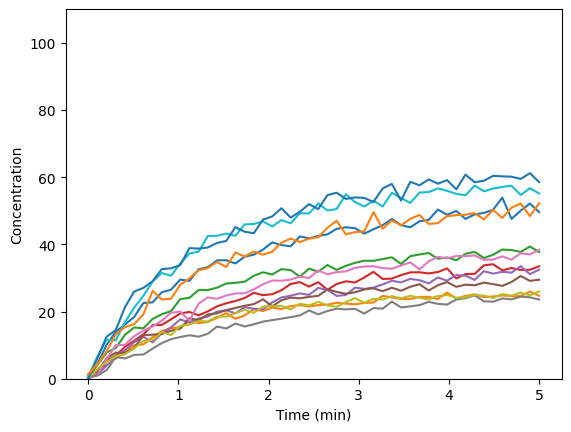

In [2]:
# Visualize kinetics for each sample on a single plot
t = ds.get_t().numpy()
for i in range(batch_size):
    sett = ds[i]
    y = sett['y'].numpy()
    plt.plot(t/60, y, label=f'Sample {i}')
plt.xlabel('Time (min)')
plt.ylabel('Concentration')
plt.ylim(0, max(y0['S_2'][1]*1.1, y0['S_1'][1]*1.1))
plt.show()

In [3]:
# Get the data loaders ready
n_total = len(ds)
n_train = 10
n_test = 3
n_val = n_total - n_train - n_test

train_ds, test_ds, val_ds = torch.utils.data.random_split(
    ds, [n_train, n_test, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader, test_loader, val_loader = get_data_loaders(
    train_ds, test_ds, val_ds,
    batch_size=2
)

In [4]:

for i, batch in enumerate(train_loader):
    if i < 1:
        print(f'Batch {i}:')
        print('c0:', batch['c0'])
        print('y:', batch['y'])
        print()


Batch 0:
c0: tensor([[64.1765, 65.0660,  0.0000],
        [58.6978, 71.9439,  0.0000]])
y: tensor([[ 1.2981,  4.3697,  8.1228, 13.2373, 15.3496, 16.2532, 19.1621, 26.1517,
         23.5673, 23.8236, 27.9489, 29.8551, 32.3143, 32.9316, 34.7572, 33.2349,
         37.5824, 36.3691, 37.8441, 36.9123, 37.7998, 40.4866, 41.7065, 40.6855,
         41.6824, 42.1075, 44.9252, 46.9927, 42.9773, 43.6162, 43.8666, 49.5925,
         44.6213, 47.1130, 45.6341, 47.5996, 48.7297, 46.0742, 46.3120, 48.4069,
         48.6724, 48.8097, 49.2702, 47.4161, 50.2497, 47.8558, 50.9127, 52.1474,
         48.3807, 52.2133],
        [ 0.0000,  4.3767, 10.0586, 13.9747, 16.1457, 18.3966, 22.5433, 22.7307,
         25.7412, 26.5031, 29.4961, 29.1232, 32.5775, 33.1976, 35.2155, 35.2693,
         34.3074, 36.3221, 36.9142, 38.4345, 40.5727, 39.7769, 39.4064, 42.3592,
         41.7682, 42.4991, 42.9760, 44.5996, 45.0833, 44.7974, 43.1758, 44.4965,
         45.7051, 47.5410, 45.7144, 45.0552, 46.8652, 47.2715, 50.3518,

# Known species experiment

In [ ]:
# global constants pulled from the *base dataset*
base_ds = train_ds.dataset  # original KineticDataset
A_control = base_ds.get_A().detach().cpu().numpy()         # for scipy.null_space
out_ind = base_ds.get_output_index()
out_ind = int(out_ind.item()) if torch.is_tensor(out_ind) else int(out_ind)

num_reactions = 1
lr = 1e-4
epochs = 1000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CRNN(A_control, num_reactions).to(device)

# Loss function and optimizer
loss_fn = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=lr)  # Stochastic Gradient Descent optimizer


t_train = base_ds.get_t().to(device).float()


loss_hist = []
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0

    for batch_idx, batch in enumerate(train_loader):
        c0 = batch["c0"].to(device).float()
        y_true = batch["y"].to(device).float()
        if y_true.dim() == 2:
            y_true = y_true.unsqueeze(-1)  # (B, T, 1)
        optimizer.zero_grad(set_to_none=True)

        y_full = model(t_train, c0)              # (B, T, N)
        y_pred = y_full[:, :, out_ind:out_ind + 1] # (B, T, 1)
 
        loss_value = loss_fn(y_pred, y_true)
        loss_value.backward()
        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )
        optimizer.step()

        epoch_loss += loss_value.item()

    epoch_loss /= len(train_loader)
    loss_hist.append(epoch_loss)

    if epoch % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} | loss {epoch_loss:.6f}")

# print final loss, plot history, and report paramaters
print(f"Final training loss: {loss_hist[-1]:.6f}")

Epoch 1/1000 | loss 978.084241


Epoch 11/1000 | loss 974.858435
Epoch 21/1000 | loss 971.124969
Epoch 31/1000 | loss 967.092926
Epoch 41/1000 | loss 962.796082
Epoch 51/1000 | loss 958.277344
Epoch 61/1000 | loss 953.436646
Epoch 71/1000 | loss 948.366968
Epoch 81/1000 | loss 942.978180
Epoch 91/1000 | loss 937.278149
Epoch 101/1000 | loss 931.325928
Epoch 111/1000 | loss 925.018536
Epoch 121/1000 | loss 918.409467
Epoch 131/1000 | loss 911.424939
Epoch 141/1000 | loss 904.079950
Epoch 151/1000 | loss 896.427081
Epoch 161/1000 | loss 888.422034
Epoch 171/1000 | loss 879.964929
Epoch 181/1000 | loss 871.243073
Epoch 191/1000 | loss 862.037891
Epoch 201/1000 | loss 852.425281
Epoch 211/1000 | loss 842.536560
Epoch 221/1000 | loss 832.121338
Epoch 231/1000 | loss 821.279877
Epoch 241/1000 | loss 810.056458
Epoch 251/1000 | loss 798.307275
Epoch 261/1000 | loss 786.190344
Epoch 271/1000 | loss 773.542206
Epoch 281/1000 | loss 760.505328
Epoch 291/1000 | loss 747.144128
Epoch 301/1000 | loss 733.109515
Epoch 311/1000 | lo

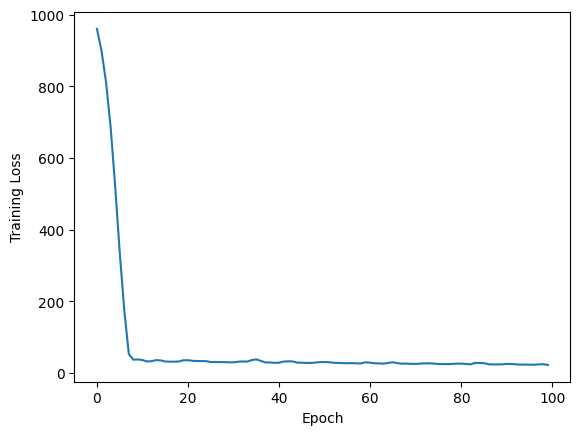

Learned reaction rates: [5.6310584e+07]
Reaction stoiciometry
[[-0.35328525]
 [-0.35328522]
 [ 0.35328525]]


In [7]:
plt.plot(loss_hist)
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.show()
print('Learned reaction rates:', np.exp(model.log_k.detach().cpu().numpy())*1e9)  # in M^-1 s^-1
print('Reaction stoiciometry')
print(-1*model.nu().detach().numpy())

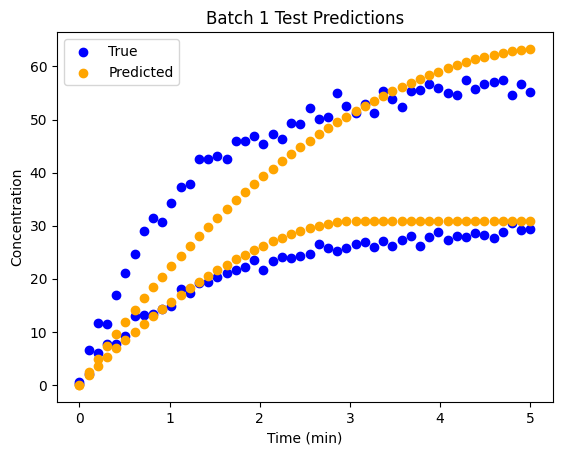

In [8]:
# Plot test predictions over test loader
model.eval()
with torch.no_grad():
    for i, batch in enumerate(test_loader):
        c0 = batch["c0"].to(device)
        y_true = batch["y"].to(device)

        y_full = model(t_train, c0)
        y_pred = y_full[:, :, out_ind]

        t_np = t_train.cpu().numpy()
        y_true_np = y_true.cpu().numpy()
        y_pred_np = y_pred.cpu().numpy()
        for j in range(len(y_true_np)):
            if j == 0:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue', label="True")
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange', label="Predicted")
            else:
                plt.scatter(t_np/60, y_true_np[j], color = 'blue')
                plt.scatter(t_np/60, y_pred_np[j], color = 'orange')
        plt.title(f"Batch {i+1} Test Predictions")
        plt.xlabel("Time (min)")
        plt.ylabel("Concentration")
        plt.legend()
        plt.show()

# Unknown spexies experiment